Stock Performance and visualisation dashboard ** data Wrangling and EDA **

## Stock vision - data ingestion , data wrangling , eda 

In [17]:
%pip install plotly

  Using cached plotly-6.7.0-py3-none-any.whl.metadata (8.6 kB)
Using cached plotly-6.7.0-py3-none-any.whl (9.9 MB)

   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]
   ---------------------------------------- 0/2 [narwhals]


[notice] A new release of pip is available: 26.0.1 -> 26.1
[notice] To update, run: C:\Users\Vanshika negi\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


In [2]:
#data ingestion + data wrangling + eda
import plotly as plt
from IPython.display import display,HTML
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns
import yfinance as yf

In [3]:
Universe = {"equity" :['ENGINERSIN.NS','POLYCAB.NS','PARAS.NS'],
           "Commodities" :["GC=F",    # Gold
        "CL=F",    # Crude Oil
        "NG=F" ]}
# 1 year data for both 
df_equity = yf.download(Universe['equity'], period='1y')
df_commodities = yf.download(Universe['Commodities'],period='1y')                       
#loaded the data 
#data ingestion stage 

[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  3 of 3 completed


In [4]:
#bsic eda to explore about data 
display(HTML("<h1 style='text-align: center;'><b>Equities</b></h1>"))
df_equity.shape #(248, 15)
df_equity.head(6) # data have date time index ( start date = 2025-05-02 )
df_equity.index #date is a index it is used fro row 
df_equity.columns #price & ticker are the colums not index 
df_equity.info() # every thing in thi sdata is in float except volume column fro tickers its in integer
df_equity.tail() #end date 2026-04-30
df_equity.ndim # its a 2D data 


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 248 entries, 2025-05-02 to 2026-04-30
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   (Close, ENGINERSIN.NS)   248 non-null    float64
 1   (Close, PARAS.NS)        248 non-null    float64
 2   (Close, POLYCAB.NS)      248 non-null    float64
 3   (High, ENGINERSIN.NS)    248 non-null    float64
 4   (High, PARAS.NS)         248 non-null    float64
 5   (High, POLYCAB.NS)       248 non-null    float64
 6   (Low, ENGINERSIN.NS)     248 non-null    float64
 7   (Low, PARAS.NS)          248 non-null    float64
 8   (Low, POLYCAB.NS)        248 non-null    float64
 9   (Open, ENGINERSIN.NS)    248 non-null    float64
 10  (Open, PARAS.NS)         248 non-null    float64
 11  (Open, POLYCAB.NS)       248 non-null    float64
 12  (Volume, ENGINERSIN.NS)  248 non-null    int64  
 13  (Volume, PARAS.NS)       248 non-null    int64  
 14  (Volume

2

In [5]:
df_equity.describe()
df_equity = df_equity[~df_equity['Volume'].eq(0).all(axis=1)] # no holiday day as day was thursday ( data missing at volume  ) 
#rechecking the dat aquality 

df_equity.isnull().sum()
df_equity.isna().sum()
#isna and isnull both are same thing , they do same operation
df_equity.describe()
#data validation checking 
(df_equity['Low'] > df_equity['High']).any()  # data valid ( as per rule teh high vlaues must be high then low vlaues )
# (df_equity['High'] > df_equity['Low']).any() ->true




Ticker
ENGINERSIN.NS    False
PARAS.NS         False
POLYCAB.NS       False
dtype: bool

In [6]:
#  data quality and data validaino   chekcing for entire dataset 
(df_equity == 0).sum().sum() # no zero value exist is perfect
(df_equity < 0).sum().sum() # no  negative value exists 



np.int64(0)

In [7]:
df_equity = df_equity.sort_index()
full_dates = pd.date_range(start=df_equity.index.min(), end=df_equity.index.max())
missing_dates = full_dates.difference(df_equity.index)
print(missing_dates) # these are holidays and weekends(market close days)


DatetimeIndex(['2025-05-03', '2025-05-04', '2025-05-10', '2025-05-11',
               '2025-05-17', '2025-05-18', '2025-05-24', '2025-05-25',
               '2025-05-31', '2025-06-01',
               ...
               '2026-04-03', '2026-04-04', '2026-04-05', '2026-04-11',
               '2026-04-12', '2026-04-14', '2026-04-18', '2026-04-19',
               '2026-04-25', '2026-04-26'],
              dtype='datetime64[ns]', length=117, freq=None)


247

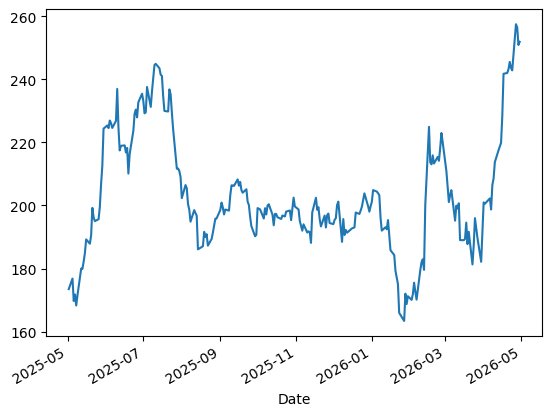

In [ ]:
# feature by feature checking and outlier detection
# trend analysis
(df_equity['Close']['ENGINERSIN.NS']).isnull().sum()
(df_equity['Close']['ENGINERSIN.NS'] <0).sum() # all positive vlaues of price 
df_equity['Close']['ENGINERSIN.NS'].plot()
len(df_equity['Close']['ENGINERSIN.NS'] ) # all  rows are plotted 






<Axes: xlabel='Date'>

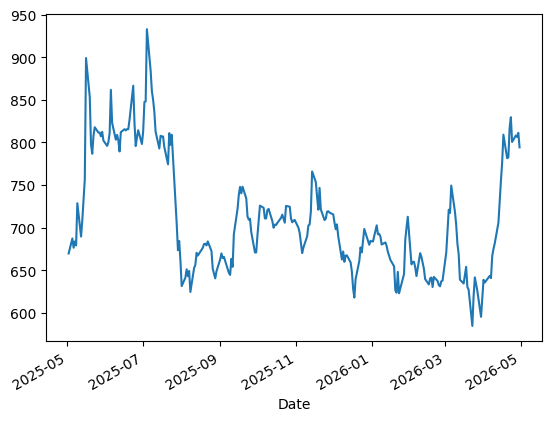

In [20]:
df_equity['Close']['PARAS.NS'].plot()
# df_equity.head()


<Axes: xlabel='Date'>

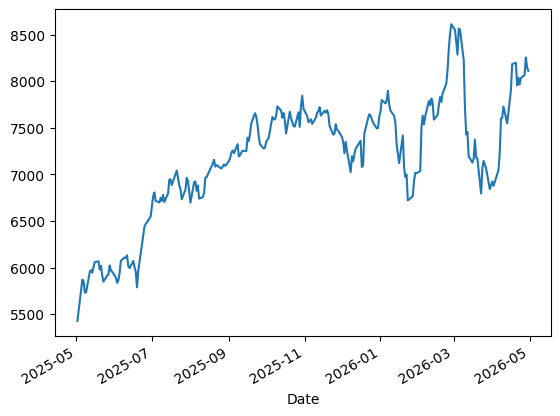

In [22]:
df_equity.head()
df_equity['Close']['POLYCAB.NS'].plot()
